CODIGO ORDENADO 
Christopher Lagos Olate


In [1]:
# PRELIMINARES 
# CARGA DE BASE DE DATOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Definir la ruta de forma robusta
# Si el CSV está en la misma carpeta que tu script (.py o .ipynb):
file_name = 'student_productivity.csv'

# Verificamos si el archivo existe en el directorio actual de trabajo
if os.path.exists(file_name):
    try:
        # Carga de la base de datos
        df = pd.read_csv(file_name)
        print(f"✅ Archivo cargado exitosamente: {file_name}")
        print(f"📊 Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
        
        # Vista rápida de los datos
        print("\nPrimeras filas:")
        print(df.head())
        
    except Exception as e:
        print(f"❌ Ocurrió un error al leer el archivo: {e}")
else:
    print(f"⚠️ Error: El archivo '{file_name}' no se encuentra en la carpeta actual.")
    print(f"Directorio actual: {os.getcwd()}")

# 2. Configuración estética para gráficos
sns.set_theme(style="whitegrid") # Actualizado de set_context para mejores visuales
plt.rcParams['figure.figsize'] = (10, 6)

✅ Archivo cargado exitosamente: student_productivity.csv
📊 Dimensiones: 5621 filas y 22 columnas.

Primeras filas:
   student_id   age  gender  academic_level  study_hours  self_study_hours  \
0           1  20.0     NaN   Undergraduate         5.37              2.09   
1           2  16.0  Female     High School         5.85              5.04   
2           3  18.0  Female   Undergraduate         5.69              2.27   
3           4  24.0    Male  Undergraduate          2.32              1.06   
4           5  24.0  Female    Postgraduate         3.87              2.63   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  1.85                3.66          2.32         7.73  ...   
1                  1.87                3.60          2.79         6.11  ...   
2                  0.00                2.93          3.94         7.11  ...   
3                  2.30                4.34          2.37         8.54  ...   
4                  2.

In [2]:
# visualizacion de los datos
# Verificación de tipos de datos
print("--- Tipos de Datos por Columna ---")
print(df.dtypes)

# Visualización de las primeras filas para inspección visual
df.head()

--- Tipos de Datos por Columna ---
student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


In [3]:
# REVISAR CODIGO 
import pandas as pd
import numpy as np

# Trabajamos sobre la base filtrada (la que tiene 10 o menos nulos)
df_final = df_filtrado.copy()

# 1. Variable indicadora "Exam" (1 si rindió, 0 si no)
# Se basa en la existencia de una nota válida
df_final['Exam'] = np.where(df_final['exam_score'] > 0, 1, 0)

# 2. Variable indicadora "gaming_hours_Index" 
# (1 si registra horas de juego > 0, 0 si es 0 o NaN)
df_final['gaming_hours_Index'] = np.where(df_final['gaming_hours'] > 0, 1, 0)

# 3. Variable indicadora "online_classes_hours_index"
# (1 si registra asistencia a clases online > 0, 0 si es 0 o NaN)
df_final['online_classes_hours_index'] = np.where(df_final['online_classes_hours'] > 0, 1, 0)

# 4. Transformación: exercise_minutes a exercise_hours (Numérica)
# Aseguramos conversión a float para el cálculo
df_final['exercise_minutes'] = pd.to_numeric(df_final['exercise_minutes'], errors='coerce')
df_final['exercise_hours'] = df_final['exercise_minutes'] / 60

# 5. Variable indicadora "exercise_hours_index"
# (0 indica no respondió o es NaN/0, 1 indica que sí registró actividad)
df_final['exercise_hours_index'] = np.where(df_final['exercise_hours'] > 0, 1, 0)

# --- Reporte de verificación ---
print("="*60)
print("RESUMEN DE NUEVAS VARIABLES INDICADORAS")
print("="*60)
indices = ['Exam', 'gaming_hours_Index', 'online_classes_hours_index', 'exercise_hours_index']
for col in indices:
    print(f"\nDistribución de {col}:")
    print(df_final[col].value_counts(normalize=True).map('{:.2%}'.format))

print("\nEstadísticas de exercise_hours (Post-conversión):")
print(df_final['exercise_hours'].describe())
print("="*60)

NameError: name 'df_filtrado' is not defined

-----------------------------------------INICIO CODIGOS ----------------------------------------------

In [4]:
#PREGUNTA 1
#LIMPIEZA DE LA BASE DE DATOS 
import pandas as pd
import numpy as np

# 1. EXCLUIR CASOS (Umbral > 15 NaNs)
# Evaluamos nulos sin considerar 'exam_score' para no sesgar la variable 'Exam'
columnas_estudio = [col for col in df.columns if col not in ['exam_score', 'student_id']]
df_limpio = df[df[columnas_estudio].isnull().sum(axis=1) <= 15].copy()

# 2. VARIABLE INDICADORA E INGENIERÍA
# Variable 'Exam': 0 si la nota es 1.0 (no rindió), 1 en caso contrario
df_limpio['Exam'] = np.where(df_limpio['exam_score'] > 1.0, 1, 0)

# Dummy "gaming_hours_Index"
df_limpio['gaming_hours_Index'] = np.where(df_limpio['gaming_hours'] > 0, 1, 0)

# Dummy "online_classes_hours_index"
df_limpio['online_classes_hours_index'] = np.where(df_limpio['online_classes_hours'] > 0, 1, 0)

# Transformación de ejercicio (Minutos a Horas y Dummy Index)
df_limpio['exercise_minutes'] = pd.to_numeric(df_limpio['exercise_minutes'], errors='coerce')
df_limpio['exercise_hours'] = df_limpio['exercise_minutes'] / 60
df_limpio['exercise_hours_index'] = np.where(df_limpio['exercise_hours'] > 0, 1, 0)

# Eliminamos la original de minutos
df_limpio = df_limpio.drop(columns=['exercise_minutes'])


# 4. IMPUTACIÓN Y NORMALIZACIÓN
# 4.3) Quitar drug_use por exceso de NAs
if 'drug_use' in df_limpio.columns:
    df_limpio = df_limpio.drop(columns=['drug_use'])

# 4.1, 4.2, 4.5) Normalización de categóricas y corregir duplicados
cats = ['gender', 'academic_level', 'part_time_job']
for col in cats:
    if col in df_limpio.columns:
        # Quitar espacios, estandarizar mayúsculas (soluciona Yes/yes, Undergraduate/undergraduate)
        df_limpio[col] = df_limpio[col].astype(str).str.strip().str.capitalize()
        # Rellenar vacíos con 'Other'
        df_limpio[col] = df_limpio[col].replace(['Nan', 'None', 'Null', ''], 'Other')

# 4.4) Imputación de numéricas con la media
num_cols = df_limpio.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if col not in ['student_id', 'exam_score', 'Exam']:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mean())

# RESULTADOS FINALES
filas_finales, columnas_finales = df_limpio.shape

print("="*60)
print("PROCESAMIENTO COMPLETO DE BASE DE DATOS")
print("="*60)
print(f"Cantidad de FILAS finales:    {filas_finales}")
print(f"Cantidad de COLUMNAS finales: {columnas_finales}")
print("-" * 60)
print("Distribución de la variable 'Exam' (Asistencia):")
print(df_limpio['Exam'].value_counts())
print("="*60)

# Guardamos como la nueva base limpia
df_final = df_limpio

PROCESAMIENTO COMPLETO DE BASE DE DATOS
Cantidad de FILAS finales:    5193
Cantidad de COLUMNAS finales: 25
------------------------------------------------------------
Distribución de la variable 'Exam' (Asistencia):
1    4416
0     777
Name: Exam, dtype: int64


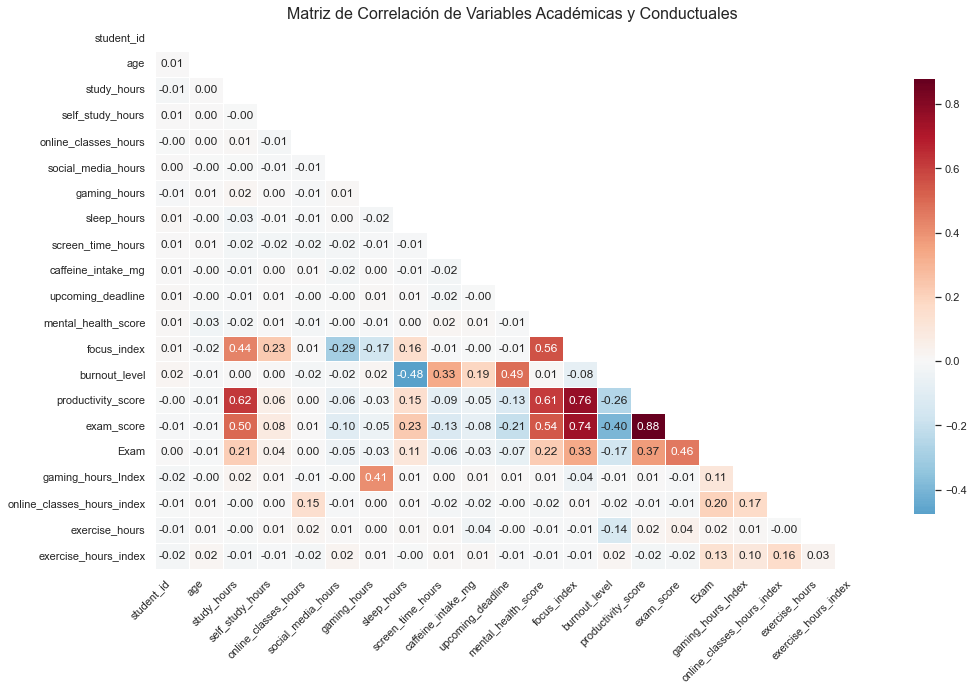

CORRELACIÓN DE LAS VARIABLES CON LA ASISTENCIA (EXAM)
Exam                          1.000000
exam_score                    0.460819
productivity_score            0.370930
focus_index                   0.327737
mental_health_score           0.221564
study_hours                   0.213909
online_classes_hours_index    0.203434
exercise_hours_index          0.131899
gaming_hours_Index            0.106942
sleep_hours                   0.105735
self_study_hours              0.036543
exercise_hours                0.016543
online_classes_hours          0.004653
student_id                    0.003446
age                          -0.008652
gaming_hours                 -0.030949
caffeine_intake_mg           -0.032612
social_media_hours           -0.046819
screen_time_hours            -0.059265
upcoming_deadline            -0.072060
burnout_level                -0.167225
Name: Exam, dtype: float64


In [5]:
#MATRIZ DE CORRELACION 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionamos solo las variables numéricas para la correlación
# Incluimos las dummies y los índices que creamos
df_corr = df_limpio.select_dtypes(include=[np.number])

# 2. Calcular la matriz de correlación
matriz_corr = df_corr.corr()

# 3. Configuración del gráfico (Heatmap)
plt.figure(figsize=(16, 10))

# Creamos una máscara para ver solo la mitad inferior (opcional, evita duplicados)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Dibujar el heatmap
sns.heatmap(matriz_corr, 
            mask=mask, 
            annot=True,          # Muestra los números dentro de los cuadros
            fmt=".2f",           # Dos decimales
            cmap='RdBu_r',       # Color: Rojo (negativo) a Azul (positivo)
            center=0,            # El blanco es el 0
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Variables Académicas y Conductuales', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Mostrar las correlaciones más altas con la variable "Exam"
print("="*60)
print("CORRELACIÓN DE LAS VARIABLES CON LA ASISTENCIA (EXAM)")
print("="*60)
print(matriz_corr['Exam'].sort_values(ascending=False))

In [6]:
#PREGUNTA 2.1
#Modelo MCO COMPLETO 
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de variables categóricas
# Convertimos variables como 'gender' y 'academic_level' en dummies numéricas
df_mco = pd.get_dummies(df_limpio, drop_first=True)

# 2. Definición de variables
# Excluimos 'exam_score' (porque define a Exam) y 'student_id'
X = df_mco.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore')
y = df_mco['Exam']

# 3. Asegurar que todos los datos sean flotantes para evitar errores de cálculo
X = X.astype(float)

# 4. Añadir la constante (Intercepto)
X = sm.add_constant(X)

# 5. Ajuste del modelo MCO (OLS)
modelo_asistencia = sm.OLS(y, X).fit()

# 6. Mostrar el resumen de resultados
print(modelo_asistencia.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     69.39
Date:              jue., 16 abr. 2026   Prob (F-statistic):          1.39e-321
Time:                        22:23:34   Log-Likelihood:                -1211.8
No. Observations:                5193   AIC:                             2480.
Df Residuals:                    5165   BIC:                             2663.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [7]:
#PREGUNTA 2.2
#MODELO MCO SIGNIFICATIVO 
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables originales que resultaron significativas (o contienen categorías significativas)
vars_originales_sig = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene gender_Other
    'academic_level',   # Contiene Undergraduate y Other
    'part_time_job',    # Contiene Other
    'internet_quality'  # Contiene Good
]

# 2. Creamos un nuevo DataFrame solo con estas variables + la dependiente
df_reducido = df_limpio[vars_originales_sig + ['Exam']].copy()

# 3. Convertimos las categóricas en dummies (Numéricas para el modelo)
# drop_first=True es vital para evitar la trampa de la variable ficticia
df_final_model = pd.get_dummies(df_reducido, drop_first=True)

# 4. Definir X e y
y = df_final_model['Exam']
X = df_final_model.drop(columns=['Exam']).astype(float)

# 5. Añadir constante
X = sm.add_constant(X)

# 6. Ajustar modelo final
modelo_final = sm.OLS(y, X).fit()

# 7. Resultados
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     124.8
Date:              jue., 16 abr. 2026   Prob (F-statistic):               0.00
Time:                        22:35:34   Log-Likelihood:                -1214.1
No. Observations:                5193   AIC:                             2460.
Df Residuals:                    5177   BIC:                             2565.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [8]:
#PREGUNTA 2.3
#MODELO MCO CON VARIABLES DE INTERES SIN CORRELACION (entre variables predictoras )
import statsmodels.api as sm
import pandas as pd

# 1. Selección de variables solicitadas
# Nota: Usamos df_limpio que ya tiene las transformaciones y limpieza final
vars_modelo = [
    'gaming_hours',
    'exercise_hours',
    'mental_health_score',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index'
]

# 2. Preparación de matrices
# Aseguramos que los datos sean numéricos y manejables por el algoritmo
X = df_limpio[vars_modelo].astype(float)
y = df_limpio['Exam']

# 3. Añadir la constante (Intercepto)
# Indispensable en MCO para que los residuos tengan media cero
X = sm.add_constant(X)

# 4. Ajuste del modelo MCO (OLS)
modelo_conductual = sm.OLS(y, X).fit()

# 5. Visualización de resultados
print("="*60)
print("MODELO MCO: DETERMINANTES CONDUCTUALES DE LA ASISTENCIA")
print("="*60)
print(modelo_conductual.summary())

# 6. Guardar coeficientes para análisis rápido
coeficientes = modelo_conductual.params
print("\nInterpretación rápida de coeficientes:")
print(coeficientes)

MODELO MCO: DETERMINANTES CONDUCTUALES DE LA ASISTENCIA
                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     196.8
Date:              jue., 16 abr. 2026   Prob (F-statistic):          1.17e-226
Time:                        22:38:16   Log-Likelihood:                -1482.7
No. Observations:                5193   AIC:                             2979.
Df Residuals:                    5186   BIC:                             3025.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [9]:
#PREGUNTA 3.1
#modelo provit 
import statsmodels.api as sm
import pandas as pd

# 1. Preparación de datos (Dummies y limpieza de nombres)
df_probit = pd.get_dummies(df_limpio, drop_first=True)
X = df_probit.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore')
y = df_probit['Exam']
X = sm.add_constant(X).astype(float)

# 2. AJUSTE DEL MODELO PROBIT (Summary estándar)
# Este paso es necesario para ver el ajuste global del modelo
modelo_probit = sm.Probit(y, X).fit()

print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO PROBIT (Coeficientes Beta)")
print("="*80)
print(modelo_probit.summary())

# 3. CÁLCULO DE EFECTOS MARGINALES (dy/dx)
# Calculamos el Efecto Marginal Promedio (AME)
probit_margeff = modelo_probit.get_margeff(at='overall', method='dydx')

print("\n" + "="*80)
print("2. EFECTOS MARGINALES DEL MODELO PROBIT (Interpretación dy/dx)")
print("="*80)
print(probit_margeff.summary())


Optimization terminated successfully.
         Current function value: 0.282062
         Iterations 7

1. RESUMEN GLOBAL DEL MODELO PROBIT (Coeficientes Beta)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5193
Model:                         Probit   Df Residuals:                     5165
Method:                           MLE   Df Model:                           27
Date:              jue., 16 abr. 2026   Pseudo R-squ.:                  0.3317
Time:                        22:41:37   Log-Likelihood:                -1464.7
converged:                       True   LL-Null:                       -2191.7
Covariance Type:            nonrobust   LLR p-value:                6.504e-290
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const          

In [11]:
#PREGUNTA 3.2
#modelo probit significativo 
import statsmodels.api as sm
import pandas as pd

# 1. Lista de variables originales que contienen categorías significativas
vars_originales = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene 'Other'
    'academic_level',   # Contiene 'Undergraduate' y 'Other'
    'part_time_job',    # Contiene 'Other'
    'internet_quality'  # Contiene 'Good'
]

# 2. Preparación del DataFrame
# Seleccionamos las columnas y creamos dummies automáticamente
df_model = pd.get_dummies(df_limpio[vars_originales + ['Exam']], drop_first=True)

# 3. Definir X e y
y = df_model['Exam']
X = df_model.drop(columns=['Exam']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Probit
modelo_probit_final = sm.Probit(y, X).fit()

# 5. RESULTADOS: Summary y Efectos Marginales
print("\n" + "="*80)
print("1. RESUMEN GLOBAL (COEFICIENTES BETA)")
print("="*80)
print(modelo_probit_final.summary())

# Cálculo de dy/dx
margeff_final = modelo_probit_final.get_margeff(at='overall', method='dydx')

print("\n" + "="*80)
print("2. EFECTOS MARGINALES (INTERPRETACIÓN dy/dx)")
print("="*80)
print(margeff_final.summary())


Optimization terminated successfully.
         Current function value: 0.282605
         Iterations 7

1. RESUMEN GLOBAL (COEFICIENTES BETA)
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5193
Model:                         Probit   Df Residuals:                     5177
Method:                           MLE   Df Model:                           15
Date:              jue., 16 abr. 2026   Pseudo R-squ.:                  0.3304
Time:                        22:49:33   Log-Likelihood:                -1467.6
converged:                       True   LL-Null:                       -2191.7
Covariance Type:            nonrobust   LLR p-value:                6.551e-300
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -

In [12]:
#PREGUNTA 4.1
#modelo logit completo
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparación de los datos (Dummies automáticas)
df_logit = pd.get_dummies(df_limpio, drop_first=True)

# 2. Definición de variables (Variables originales significativas según tus pruebas)
# Eliminamos los IDs y la nota del examen para evitar sesgos
X = df_logit.drop(columns=['Exam', 'exam_score', 'student_id'], errors='ignore').astype(float)
y = df_logit['Exam']

# 3. Añadir constante
X = sm.add_constant(X)

# 4. Ajuste del modelo Logit
modelo_logit = sm.Logit(y, X).fit()

# 5. RESULTADOS: Resumen Global y Coeficientes Log-Odds
print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO LOGIT")
print("="*80)
print(modelo_logit.summary())

# 6. RESULTADOS: Odds Ratios (Interpretación de ventajas)
print("\n" + "="*80)
print("2. ODDS RATIOS (Interpretación de Probabilidades Relativas)")
print("="*80)
odds_ratios = np.exp(modelo_logit.params)
print(odds_ratios)

# 7. RESULTADOS: Efectos Marginales (dy/dx para probabilidad directa)
print("\n" + "="*80)
print("3. EFECTOS MARGINALES (Cambio en probabilidad porcentual)")
print("="*80)
margeff_logit = modelo_logit.get_margeff(at='overall', method='dydx')
print(margeff_logit.summary())


Optimization terminated successfully.
         Current function value: 0.275469
         Iterations 8

1. RESUMEN GLOBAL DEL MODELO LOGIT
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 5193
Model:                          Logit   Df Residuals:                     5165
Method:                           MLE   Df Model:                           27
Date:              jue., 16 abr. 2026   Pseudo R-squ.:                  0.3473
Time:                        22:53:43   Log-Likelihood:                -1430.5
converged:                       True   LL-Null:                       -2191.7
Covariance Type:            nonrobust   LLR p-value:                1.564e-304
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.0

In [ ]:
#PREGUNTA 4.2
#Modelo logit significativo 
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Definimos las variables originales que contienen las categorías significativas
vars_originales_logit = [
    'focus_index', 
    'burnout_level', 
    'productivity_score', 
    'gaming_hours_Index', 
    'online_classes_hours_index', 
    'exercise_hours_index',
    'gender',           # Contiene gender_Other
    'academic_level',   # Contiene academic_level_Other y _Undergraduate
    'part_time_job',    # Contiene part_time_job_Other
    'internet_quality'  # Contiene internet_quality_Good
]

# 2. Preparación del DataFrame y creación de dummies
df_model_logit = pd.get_dummies(df_limpio[vars_originales_logit + ['Exam']], drop_first=True)

# 3. Definir X e y (asegurando tipo float para los cálculos del Logit)
y = df_model_logit['Exam']
X = df_model_logit.drop(columns=['Exam']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Logit
modelo_logit_final = sm.Logit(y, X).fit()

# 5. RESULTADOS: Resumen y Estadísticos de Ajuste
print("\n" + "="*80)
print("1. RESUMEN GLOBAL DEL MODELO LOGIT (Coeficientes Beta)")
print("="*80)
print(modelo_logit_final.summary())

# 6. RESULTADOS: Odds Ratios (Interpretación de Ventaja Relativa)
print("\n" + "="*80)
print("2. ODDS RATIOS (Exp(Beta))")
print("="*80)
print(np.exp(modelo_logit_final.params))

# 7. RESULTADOS: Efectos Marginales (dy/dx para probabilidad directa)
margeff_logit_final = modelo_logit_final.get_margeff(at='overall', method='dydx')
print("\n" + "="*80)
print("3. EFECTOS MARGINALES DEL MODELO LOGIT (Interpretación dy/dx)")
print("="*80)
print(margeff_logit_final.summary())

In [ ]:
#PREGUNTA 6.1
#MODELO POISSON (6) TODAS LAS VARIABLES
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Filtrado: Solo alumnos que rindieron el examen
# Es fundamental modelar el desempeño solo sobre la población observada
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Preparación de variables (Creación de dummies para todas las categóricas)
# Excluimos 'Exam' porque ya es constante (1) y 'student_id'
df_poisson_full = pd.get_dummies(df_asistentes.drop(columns=['student_id', 'Exam'], errors='ignore'), drop_first=True)

# 3. Definir variable dependiente e independientes
y = df_poisson_full['exam_score']
X = df_poisson_full.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo de Poisson
# Usamos el Modelo Lineal Generalizado (GLM) con familia Poisson
modelo_poisson_full = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 5. Resultados
print("\n" + "="*80)
print("RESUMEN DEL MODELO POISSON COMPLETO (Determinantes de la Nota)")
print("="*80)
print(modelo_poisson_full.summary())

# 6. Cálculo de los Incidence Rate Ratios (IRR)
# El IRR es vital para la interpretación en Poisson
irr_full = np.exp(modelo_poisson_full.params)
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
print(irr_full)

In [ ]:
#PREGUNTA 6.2
#Modelo poisson significativo 
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Selección de variables originales significativas
# Agrupamos las categorías en sus variables madre
vars_poisson_sig = [
    'study_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index',
    'academic_level', # Contiene la categoría 'Other' significativa
    'part_time_job'   # Contiene la categoría 'Other' significativa
]

# 2. Preparación de los datos (Filtrado por Exam == 1)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()
df_final_poisson = pd.get_dummies(df_asistentes[vars_poisson_sig + ['exam_score']], drop_first=True)

# 3. Definición de X e y
y = df_final_poisson['exam_score']
X = df_final_poisson.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo GLM Poisson
modelo_poisson_parsimonioso = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 5. RESULTADOS
print("\n" + "="*80)
print("RESUMEN DEL MODELO POISSON FINAL (Variables Significativas)")
print("="*80)
print(modelo_poisson_parsimonioso.summary())

# 6. INCIDENCE RATE RATIOS (IRR) - El corazón de la interpretación
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
irr_final = np.exp(modelo_poisson_parsimonioso.params)
print(irr_final)

In [ ]:
#PREGUNTA 7 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 1. Preparación de datos (Solo quienes rindieron el examen)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Ajuste del Modelo Poisson Base (con variables significativas previas)
# Nota: Poisson asume que Media = Varianza
X_poisson = pd.get_dummies(df_asistentes[['study_hours', 'mental_health_score', 'focus_index', 
                                         'burnout_level', 'productivity_score']], drop_first=True)
X_poisson = sm.add_constant(X_poisson).astype(float)
y = df_asistentes['exam_score']

modelo_p = sm.GLM(y, X_poisson, family=sm.families.Poisson()).fit()

# 3. Determinación de la Sobredispersión (Ratio de Pearson)
pearson_ratio = modelo_p.pearson_chi2 / modelo_p.df_resid
print(f"Ratio de Dispersión de Pearson: {pearson_ratio:.4f}")

# 4. Cálculo del valor óptimo de Alpha (α)
# Ajustamos un modelo de Binomial Negativa para estimar el parámetro de dispersión
# En statsmodels, el alpha óptimo se encuentra ajustando un modelo de la familia NegativeBinomial
modelo_nb = sm.GLM(y, X_poisson, family=sm.families.NegativeBinomial(alpha=0.1)).fit()

# Para obtener el alpha exacto, usamos un procedimiento de optimización o el modelo auxiliar
df_asistentes['mu'] = modelo_p.predict(X_poisson)
df_asistentes['aux_var'] = ((df_asistentes['exam_score'] - df_asistentes['mu'])**2 - df_asistentes['mu']) / df_asistentes['mu']

# Regresión auxiliar para encontrar alpha (Cameron & Trivedi)
aux_model = sm.OLS(df_asistentes['aux_var'], df_asistentes['mu']).fit()
alpha_optimo = aux_model.params[0]

print(f"Valor óptimo de Alpha (α): {alpha_optimo:.6f}")
print(f"P-valor del Test de Alpha: {aux_model.pvalues[0]:.4f}")

In [ ]:
# PREGUNTA 8 
#BINOMIAL NEGATIVO SIGNIFICATIVO CORRECTO
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Preparación de la muestra (Solo estudiantes que rindieron el examen)
df_asistentes = df_limpio[df_limpio['Exam'] == 1].copy()

# 2. Definición de variables originales significativas
# Nota: Incluimos las variables base que contienen las categorías significativas
vars_finales = [
    'study_hours',
    'upcoming_deadline',
    'mental_health_score',
    'focus_index',
    'burnout_level',
    'productivity_score',
    'online_classes_hours_index',
    'academic_level',
    'part_time_job'
]

# 3. Creación de matrices y dummies
df_final_nb = pd.get_dummies(df_asistentes[vars_finales + ['exam_score']], drop_first=True)
y = df_final_nb['exam_score']
X = df_final_nb.drop(columns=['exam_score']).astype(float)
X = sm.add_constant(X)

# 4. Ajuste del Modelo Binomial Negativa
# Usamos el alpha de 0.0242 detectado en el test de sobredispersión
modelo_nb_final = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=0.0242)).fit()

# 5. Visualización de Resultados
print("\n" + "="*80)
print("RESULTADOS FINALES: REGRESIÓN BINOMIAL NEGATIVA")
print("="*80)
print(modelo_nb_final.summary())

# 6. Cálculo de los IRR para la interpretación académica
irr_final = np.exp(modelo_nb_final.params)
print("\n" + "="*40)
print("INCIDENCE RATE RATIOS (IRR)")
print("="*40)
print(irr_final)

NameError: name 'df_limpio' is not defined